# Bank Customer Churn KDD — Phase 4

## Anomaly & Outlier Detection

**Owners:** Data Engineers + Pattern Analyst  
**Decision standard:** compare IQR, Z-score, and Isolation Forest systematically; cross-reference Phase 2 DBSCAN noise; preserve a stable source-row key; and classify every flagged record as a data error, rare legitimate case, or risk signal using evidence that does **not** condition on `Exited`.

`Exited` is used only after flags/classes exist, as a post-hoc alignment lens—not anomaly ground truth and not predictive accuracy.

In [1]:
# Shared imports and project-root-aware artifact paths
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.ensemble import IsolationForest
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (
            (candidate / 'src' / '_pipeline_utils.py').is_file()
            and (candidate / 'data' / 'raw' / 'churn.csv').is_file()
        )
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        'Open this notebook from inside the Project_DATAMINING repository.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src._pipeline_utils import upsert_evaluation_metrics

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'churn.csv'
CLEAN_PATH = PROCESSED_DIR / 'churn_clean.csv'
CLUSTER_MATRIX = PROCESSED_DIR / 'churn_clustering_matrix.csv'
TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_transactions.csv'
OHE_TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_ohe_transactions.csv'
CLUSTERED_PATH = PROCESSED_DIR / 'churn_clustered.csv'
DBSCAN_OUTLIERS_PATH = PROCESSED_DIR / 'dbscan_outlier_indices.npy'
TOP_RULES_PATH = OUTPUTS_DIR / 'ph3_top_association_rules.csv'
ALL_RULES_PATH = OUTPUTS_DIR / 'ph3_all_association_rules.csv'
ANOMALY_REPORT_PATH = OUTPUTS_DIR / 'ph4_anomaly_report.csv'
HIGH_CONFIDENCE_ANOMALIES_PATH = OUTPUTS_DIR / 'ph4_high_confidence_anomalies.csv'

def require_artifacts(paths, phase_name):
    missing = [path for path in paths if not Path(path).is_file()]
    if missing:
        formatted = '\n'.join(f'  - {path}' for path in missing)
        raise FileNotFoundError(
            f'{phase_name} is missing prerequisite artifacts:\n{formatted}'
        )

print('✔ All libraries loaded successfully.')
print(f'  Project root: {PROJECT_ROOT}')
print(f'  Python:       {sys.version.split()[0]}')
print(f'  Executable:   {sys.executable}')
print(f'  Pandas:       {pd.__version__}')
print(f'  NumPy:        {np.__version__}')


✔ All libraries loaded successfully.
  Project root: c:\Users\Thomas\Documents\Project_DATAMINING
  Python:       3.11.9
  Executable:   c:\Users\Thomas\Documents\Project_DATAMINING\.venv\Scripts\python.exe
  Pandas:       2.2.2
  NumPy:        1.26.4


## Prerequisites

Requires Phase 1's clean dataset and Phase 2's positional DBSCAN outlier indices. Includes the original final synthesis and limitations.

In [2]:
require_artifacts(
    [CLEAN_PATH, DBSCAN_OUTLIERS_PATH],
    'Phase 4',
)
df = pd.read_csv(CLEAN_PATH)
_dbscan_indices = np.load(DBSCAN_OUTLIERS_PATH)
if (
    _dbscan_indices.ndim != 1
    or not np.issubdtype(_dbscan_indices.dtype, np.integer)
    or len(np.unique(_dbscan_indices)) != len(_dbscan_indices)
    or ((_dbscan_indices < 0) | (_dbscan_indices >= len(df))).any()
):
    raise ValueError(
        'Phase 4 DBSCAN indices do not align with the clean dataset. Rerun Phases 1 and 2.'
    )
print(
    f'✔ Phase 4 prerequisites loaded: {len(df):,} customers and '
    f'{len(_dbscan_indices):,} DBSCAN outliers.'
)


✔ Phase 4 prerequisites loaded: 10,000 customers and 554 DBSCAN outliers.


## Phase 4: Anomaly & Outlier Detection

**Algorithms Applied:**
1. **IQR Method** — Statistical outlier identification (1.5 × IQR rule)
2. **Z-Score Method** — Normal distribution outlier identification (|z| > 3)
3. **Isolation Forest** — Machine learning tree-based anomaly isolation
4. **Robust Mahalanobis Distance (MinCovDet)** — multivariate statistical detection *(beyond-requirement extension)*
5. **Local Outlier Factor (LOF)** — multivariate local-density detection *(beyond-requirement extension)*

**Systematic comparison plan:** the three required methods are compared pairwise, and additionally the univariate family (IQR ∪ Z-score) is compared against the multivariate family (Mahalanobis ∪ LOF ∪ Isolation Forest), with every disagreement between the families decomposed and explained.

**Strategic Focus:** Detect structural anomalies, specifically:
- Customers with sudden high Balance → Exited=1 (pre-closure balance drop signal)
- Cross-reference with DBSCAN noise points from Phase 2

**Anomaly Classification:**
- Class A: Data Error (unrealistic/impossible values)
- Class B: Rare Legitimate Case (statistically unusual but valid)
- Class C: Risk Signal (independent structural/density evidence or ARM-profile overlap)


In [3]:
# ── IQR Outlier Detection ─────────────────────────────────────────────────────
anomaly_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
df_anomaly = df.copy()
source_row_numbers = pd.read_csv(RAW_PATH, usecols=['RowNumber'])['RowNumber']
if len(source_row_numbers) != len(df_anomaly):
    raise ValueError('Raw and clean row counts differ; source-row traceability is unsafe.')
df_anomaly.insert(0, 'Source_RowNumber', source_row_numbers.to_numpy())

iqr_flags = pd.DataFrame(index=df_anomaly.index)

for col in anomaly_cols:
    q1, q3 = df_anomaly[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower  = q1 - 1.5 * iqr
    upper  = q3 + 1.5 * iqr
    
    iqr_flags[f'IQR_flag_{col}'] = (
        (df_anomaly[col] < lower) | (df_anomaly[col] > upper)
    ).astype(int)
    
    n_out = iqr_flags[f'IQR_flag_{col}'].sum()
    print(f"  {col:<20} | Lower: {lower:,.1f} | Upper: {upper:,.1f} | "
          f"Outliers: {n_out:,} ({n_out/len(df)*100:.2f}%)")

df_anomaly['IQR_outlier_count'] = iqr_flags.sum(axis=1)
df_anomaly['IQR_flag']          = (df_anomaly['IQR_outlier_count'] > 0).astype(int)

print(f"\n── IQR Summary ──")
print(f"  Records flagged (any feature): {df_anomaly['IQR_flag'].sum():,} "
      f"({df_anomaly['IQR_flag'].mean()*100:.2f}%)")
print(f"  Churn rate — IQR flagged:      "
      f"{df_anomaly[df_anomaly['IQR_flag']==1]['Exited'].mean()*100:.1f}%")
print(f"  Churn rate — IQR normal:       "
      f"{df_anomaly[df_anomaly['IQR_flag']==0]['Exited'].mean()*100:.1f}%")


  CreditScore          | Lower: 383.0 | Upper: 919.0 | Outliers: 15 (0.15%)
  Age                  | Lower: 14.0 | Upper: 62.0 | Outliers: 359 (3.59%)
  Balance              | Lower: -191,466.4 | Upper: 319,110.6 | Outliers: 0 (0.00%)
  EstimatedSalary      | Lower: -96,577.1 | Upper: 296,967.5 | Outliers: 0 (0.00%)

── IQR Summary ──
  Records flagged (any feature): 374 (3.74%)
  Churn rate — IQR flagged:      23.5%
  Churn rate — IQR normal:       20.2%


In [4]:
# ── Z-Score Outlier Detection ─────────────────────────────────────────────────
zscore_flags = pd.DataFrame(index=df_anomaly.index)

for col in anomaly_cols:
    z_scores = np.abs(stats.zscore(df_anomaly[col]))
    zscore_flags[f'Z_flag_{col}'] = (z_scores > 3).astype(int)
    n_out = zscore_flags[f'Z_flag_{col}'].sum()
    print(f"  {col:<20} | |Z| > 3 outliers: {n_out:,} ({n_out/len(df)*100:.2f}%)")

df_anomaly['ZScore_outlier_count'] = zscore_flags.sum(axis=1)
df_anomaly['ZScore_flag']          = (df_anomaly['ZScore_outlier_count'] > 0).astype(int)

# ── IQR vs Z-Score Agreement Analysis ────────────────────────────────────────
both_flagged = ((df_anomaly['IQR_flag'] == 1) & (df_anomaly['ZScore_flag'] == 1)).sum()
only_iqr     = ((df_anomaly['IQR_flag'] == 1) & (df_anomaly['ZScore_flag'] == 0)).sum()
only_z       = ((df_anomaly['IQR_flag'] == 0) & (df_anomaly['ZScore_flag'] == 1)).sum()
neither      = ((df_anomaly['IQR_flag'] == 0) & (df_anomaly['ZScore_flag'] == 0)).sum()

print(f"\n── IQR vs Z-Score Comparison ──")
print(f"  Flagged by BOTH:      {both_flagged:,}")
print(f"  Flagged by IQR only:  {only_iqr:,}")
print(f"  Flagged by Z only:    {only_z:,}")
print(f"  Flagged by NEITHER:   {neither:,}")
print(f"\n  Agreement Rate: {both_flagged/(df_anomaly['IQR_flag'].sum())*100:.1f}% of IQR outliers confirmed by Z-Score")


  CreditScore          | |Z| > 3 outliers: 8 (0.08%)
  Age                  | |Z| > 3 outliers: 133 (1.33%)
  Balance              | |Z| > 3 outliers: 0 (0.00%)
  EstimatedSalary      | |Z| > 3 outliers: 0 (0.00%)

── IQR vs Z-Score Comparison ──
  Flagged by BOTH:      141
  Flagged by IQR only:  233
  Flagged by Z only:    0
  Flagged by NEITHER:   9,626

  Agreement Rate: 37.7% of IQR outliers confirmed by Z-Score


### Interpretation — Why IQR and Z-Score Disagree (Even Though Both Are Univariate)

Both methods scan the same four columns, yet IQR flags 374 records, Z-score only 141 — and **zero records are flagged by Z alone**. The asymmetry is fully explained by fence geometry:

- **Under these distribution shapes, Z's fence is strictly farther out, so its flags form a subset of IQR's.** Under normality the 1.5×IQR fence sits at |z| ≈ 2.7 — *inside* the |z| = 3 fence. Whatever clears z > 3 has already failed the IQR test; "Z-only = 0" is a structural outcome, not a coincidence.
- **Age (359 IQR vs. 133 Z):** the IQR fence is 62 years; the z = 3 threshold is 70.4 years. The 226 customers aged 63–70 fall in the gap and are IQR-only. Worse for Z: the right-skewed senior tail *inflates the standard deviation used to compute z*, pushing its own fence outward — z-scores are partially blinded by the very outliers they hunt (classical masking on skewed data), while IQR's quartiles are robust to the tail.
- **CreditScore (15 vs. 8):** same mechanics on the lower tail — IQR fence 383 vs. z fence ≈ 361, with 7 customers scoring in between.
- **Balance and EstimatedSalary (0 and 0 under both):** flat, bounded distributions cannot reach either fence. Salary is near-uniform, and a uniform variable's most extreme value sits at only |z| ≈ 1.73 (observed max: 1.74) — **z > 3 is mathematically impossible for it**. Zero flags reflect method limits, not clean data.
- **The 141 records flagged by both** are the hard core of univariate extremeness: 100% of Z flags are IQR-confirmed; 37.7% of IQR flags are Z-confirmed.

**Conclusion:** these two methods ask the *same question* ("is this single value extreme?") with different rulers, so their disagreement is one of calibration and robustness — the union (IQR ∪ Z) is carried forward and nothing is lost. Contrast this with the univariate-vs-multivariate comparison below, where the methods ask *different questions* and the disagreement is structural, revealing genuinely different kinds of anomaly.


── Isolation Forest Results (contamination=0.05) ──
  Anomalies flagged: 500 (5.0%)
  Churn rate — IF anomalies: 49.0%
  Churn rate — IF normal:    18.9%


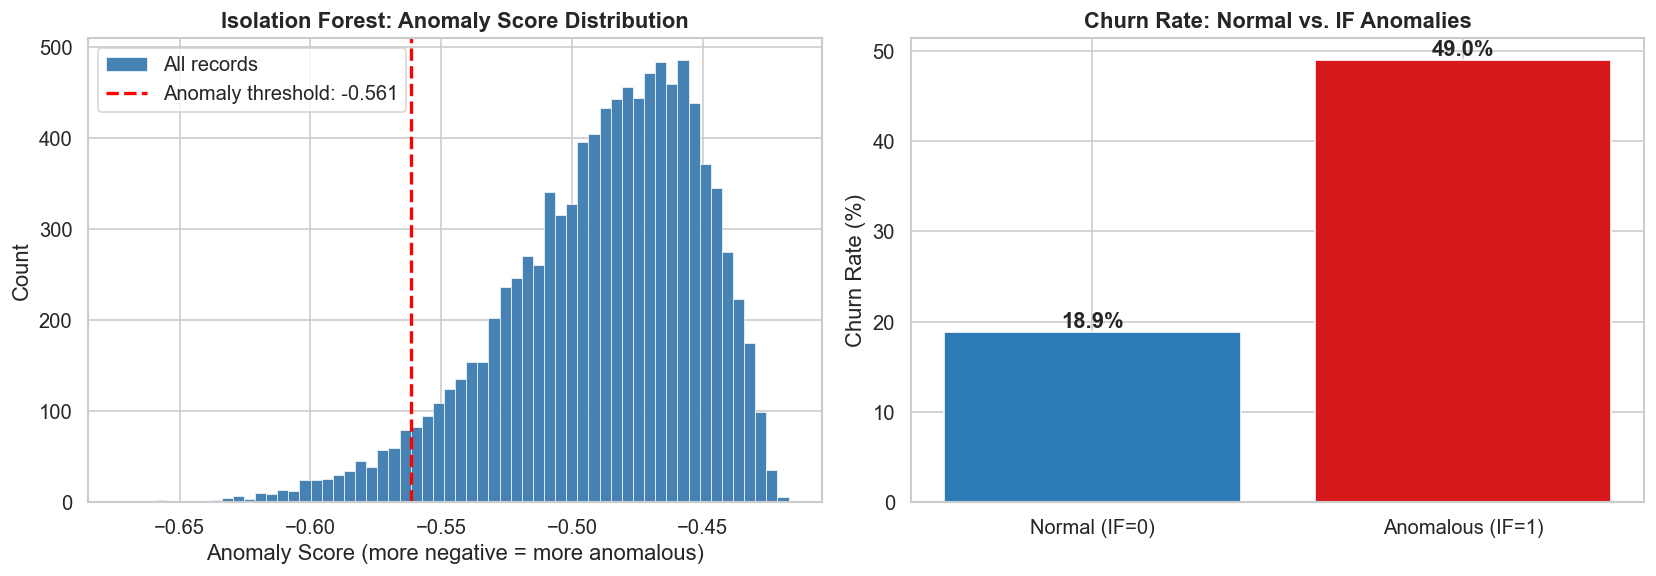

In [5]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
CONTAMINATION = 0.05   # Expect ~5% anomalies (tune based on IQR/Z-score findings)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_features=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit on scaled numeric features
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 
              'NumOfProducts', 'EstimatedSalary']
X_iso = StandardScaler().fit_transform(df_anomaly[scale_cols])

iso_labels  = iso_forest.fit_predict(X_iso)      # -1 = anomaly, 1 = normal
iso_scores  = iso_forest.score_samples(X_iso)    # More negative = more anomalous

df_anomaly['IF_flag']        = (iso_labels == -1).astype(int)
df_anomaly['IF_anomaly_score'] = iso_scores

print(f"── Isolation Forest Results (contamination={CONTAMINATION}) ──")
print(f"  Anomalies flagged: {df_anomaly['IF_flag'].sum():,} "
      f"({df_anomaly['IF_flag'].mean()*100:.1f}%)")
print(f"  Churn rate — IF anomalies: "
      f"{df_anomaly[df_anomaly['IF_flag']==1]['Exited'].mean()*100:.1f}%")
print(f"  Churn rate — IF normal:    "
      f"{df_anomaly[df_anomaly['IF_flag']==0]['Exited'].mean()*100:.1f}%")

# ── Anomaly Score Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(iso_scores, bins=60, color='steelblue', edgecolor='white',
             linewidth=0.4, label='All records')
threshold = np.percentile(iso_scores, CONTAMINATION * 100)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Anomaly threshold: {threshold:.3f}')
axes[0].set_title('Isolation Forest: Anomaly Score Distribution', fontweight='bold')
axes[0].set_xlabel('Anomaly Score (more negative = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Churn rate by flag
flag_groups = df_anomaly.groupby('IF_flag')['Exited'].mean() * 100
axes[1].bar(['Normal (IF=0)', 'Anomalous (IF=1)'], flag_groups.values,
            color=['#2c7bb6','#d7191c'])
axes[1].set_title('Churn Rate: Normal vs. IF Anomalies', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(flag_groups.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()

plt.show()


### Interpretation — Reading Isolation Forest's Numbers Correctly

- **"500 anomalies (5.0%)" is imposed, not discovered.** `contamination=0.05` fixes the flagged *quantile* by construction; the discovery is *which* 500 records rank most isolable, not how many. (IQR/Z work the opposite way: fixed fences, discovered counts. This asymmetry must be kept in mind whenever method counts are compared side by side.)
- **The discovered part is strong:** the 500 most isolable customers churn at 49.0% vs. 18.9% for the rest — a 2.6× concentration obtained *without the model ever seeing the churn label*. Because Isolation Forest evaluates all six numeric dimensions jointly, it can rank as anomalous the unusual-combination customers that per-feature fences structurally miss — the bridge to the multivariate family introduced next.
- **The score histogram shows a smooth left tail, not a separated anomaly mode**, with the threshold (−0.561) cutting through a continuum. Consistent with everything so far (weak silhouettes, near-orthogonal features): this book has no crisp normal/abnormal boundary, anomaly-ness is *graded* — which is why Phase 4 ends by classifying each flagged record individually instead of trusting a binary flag.


### Multivariate Outlier Detection — Mahalanobis Distance & Local Outlier Factor

IQR and Z-score above are **univariate**: they inspect one feature at a time, so they can only catch values that are extreme *on their own axis*. A customer whose every individual value is unremarkable can still be a glaring anomaly as a **combination** (e.g., very young with a very high balance). Two multivariate detectors are added:

- **Robust Mahalanobis distance (MinCovDet)** — *statistical*: measures each record's distance from the multivariate centre in the metric of the feature covariance, so correlated features are properly accounted for. Robust MCD estimation prevents the outliers themselves from inflating the covariance estimate ("masking"). Flag threshold: the χ² quantile at 99.9% (df = number of features), the standard cutoff for squared Mahalanobis distances.
- **Local Outlier Factor (LOF)** — *density-based*: flags records whose local neighbourhood density is far lower than that of their k=20 nearest neighbours, catching *local* anomalies a global covariance model misses. Contamination is fixed at 5% to be directly comparable with Isolation Forest.

Isolation Forest (fitted above) is also multivariate. In the comparison that follows, the three multivariate flags (Mahalanobis, LOF, IF) are grouped against the two univariate flags (IQR, Z-score), and every disagreement between the two families is decomposed and explained.

── Robust Mahalanobis Results ──
  Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
  chi2(df=6) @ 99.9% -> threshold 22.46
  Flagged: 117 (1.17%)
  (Sensitivity: @99% threshold 16.81 would flag 308 records — reported for transparency)
  Churn rate — flagged: 65.8% | normal: 19.8%


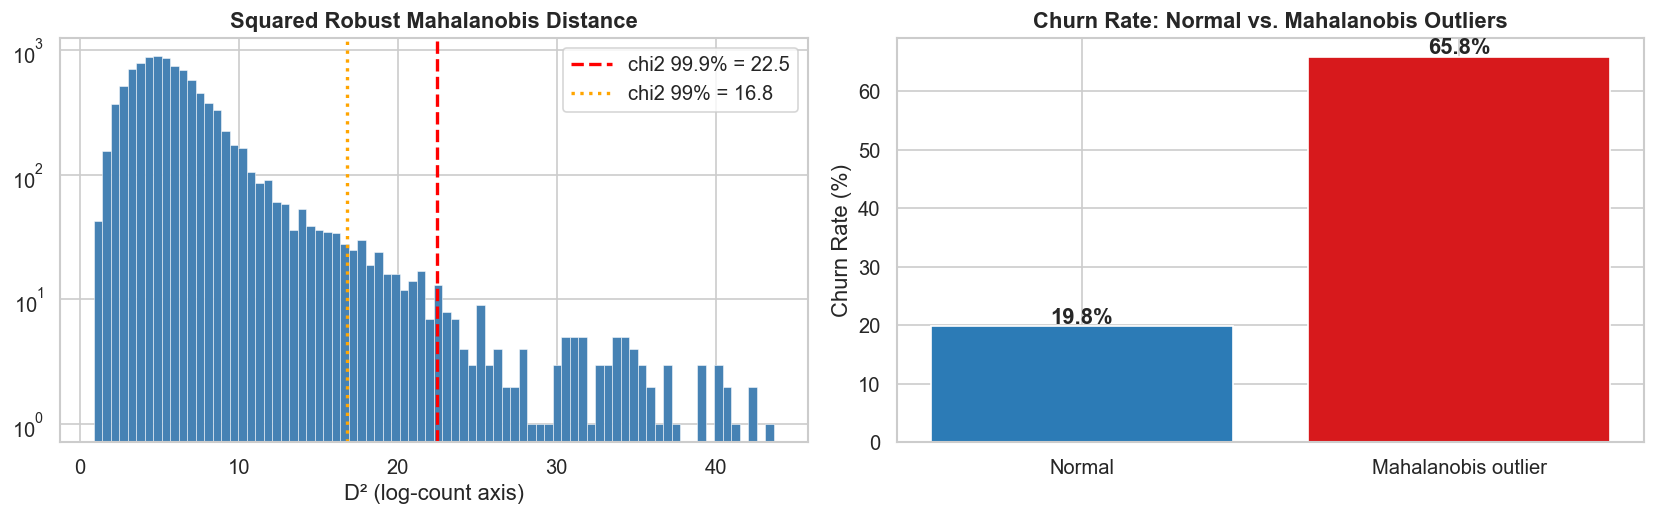

In [6]:
# ── Mahalanobis Distance (Robust, MinCovDet) ──────────────────────────────────
from sklearn.covariance import MinCovDet

X_mv = X_iso                       # same scaled feature matrix as Isolation Forest
mv_feature_names = scale_cols

mcd = MinCovDet(support_fraction=0.9, random_state=RANDOM_STATE).fit(X_mv)
maha_d2 = mcd.mahalanobis(X_mv)    # squared robust Mahalanobis distances

MAHA_Q = 0.999
maha_threshold = stats.chi2.ppf(MAHA_Q, df=X_mv.shape[1])
df_anomaly['MAHA_dist2'] = maha_d2
df_anomaly['MAHA_flag']  = (maha_d2 > maha_threshold).astype(int)

alt_thr = stats.chi2.ppf(0.99, df=X_mv.shape[1])
print(f"── Robust Mahalanobis Results ──")
print(f"  Features: {mv_feature_names}")
print(f"  chi2(df={X_mv.shape[1]}) @ 99.9% -> threshold {maha_threshold:.2f}")
print(f"  Flagged: {df_anomaly['MAHA_flag'].sum():,} "
      f"({df_anomaly['MAHA_flag'].mean()*100:.2f}%)")
print(f"  (Sensitivity: @99% threshold {alt_thr:.2f} would flag "
      f"{(maha_d2 > alt_thr).sum():,} records — reported for transparency)")
print(f"  Churn rate — flagged: "
      f"{df_anomaly.loc[df_anomaly['MAHA_flag']==1,'Exited'].mean()*100:.1f}% | "
      f"normal: {df_anomaly.loc[df_anomaly['MAHA_flag']==0,'Exited'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(maha_d2, bins=80, color='steelblue', edgecolor='white', linewidth=.3)
axes[0].axvline(maha_threshold, color='red', linestyle='--', linewidth=2,
                label=f'chi2 99.9% = {maha_threshold:.1f}')
axes[0].axvline(alt_thr, color='orange', linestyle=':', linewidth=2,
                label=f'chi2 99% = {alt_thr:.1f}')
axes[0].set_yscale('log')
axes[0].set_title('Squared Robust Mahalanobis Distance', fontweight='bold')
axes[0].set_xlabel('D² (log-count axis)')
axes[0].legend()

flag_churn = df_anomaly.groupby('MAHA_flag')['Exited'].mean() * 100
axes[1].bar(['Normal', 'Mahalanobis outlier'], flag_churn.values,
            color=['#2c7bb6', '#d7191c'])
for i, v in enumerate(flag_churn.values):
    axes[1].text(i, v + .5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate: Normal vs. Mahalanobis Outliers', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()


── LOF Results (k=20 neighbours, contamination=0.05) ──
  Flagged: 500 (5.0%)
  Churn rate — flagged: 32.4% | normal: 19.7%


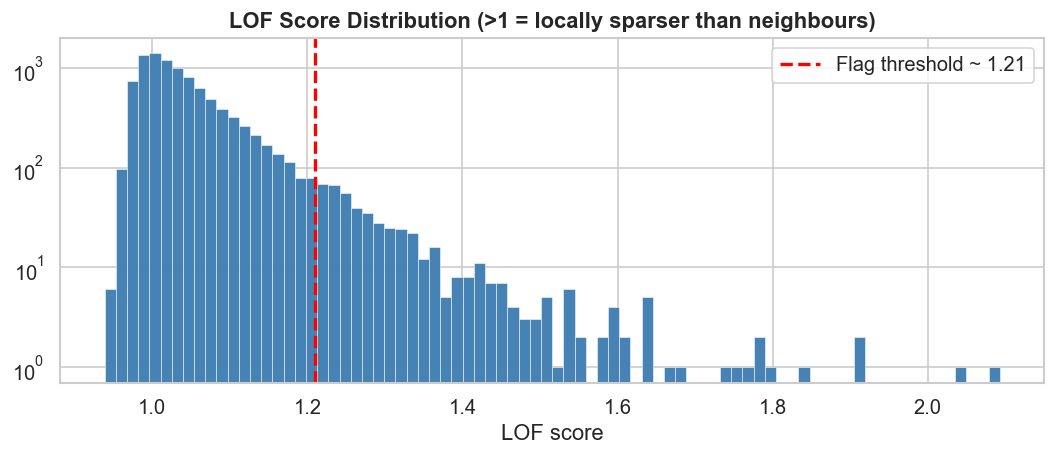

In [7]:
# ── Local Outlier Factor (LOF) ────────────────────────────────────────────────
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
lof_labels = lof.fit_predict(X_mv)
df_anomaly['LOF_flag']  = (lof_labels == -1).astype(int)
df_anomaly['LOF_score'] = -lof.negative_outlier_factor_   # >1 = sparser than neighbours

print(f"── LOF Results (k=20 neighbours, contamination={CONTAMINATION}) ──")
print(f"  Flagged: {df_anomaly['LOF_flag'].sum():,} "
      f"({df_anomaly['LOF_flag'].mean()*100:.1f}%)")
print(f"  Churn rate — flagged: "
      f"{df_anomaly.loc[df_anomaly['LOF_flag']==1,'Exited'].mean()*100:.1f}% | "
      f"normal: {df_anomaly.loc[df_anomaly['LOF_flag']==0,'Exited'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_anomaly['LOF_score'], bins=80, color='steelblue',
        edgecolor='white', linewidth=.3)
thr = df_anomaly.loc[df_anomaly['LOF_flag'] == 1, 'LOF_score'].min()
ax.axvline(thr, color='red', linestyle='--', linewidth=2,
           label=f'Flag threshold ~ {thr:.2f}')
ax.set_yscale('log')
ax.set_title('LOF Score Distribution (>1 = locally sparser than neighbours)',
             fontweight='bold')
ax.set_xlabel('LOF score')
ax.legend()
plt.tight_layout()
plt.show()


── Per-Method Summary ──


,Method,Type,Flagged,% of Data,Churn Rate (%)
0,IQR_flag,Univariate,374,3.74,23.5
1,ZScore_flag,Univariate,141,1.41,13.5
2,MAHA_flag,Multivariate,117,1.17,65.8
3,LOF_flag,Multivariate,500,5.00,32.4
4,IF_flag,Multivariate,500,5.00,49.0


── Family-Level Agreement: Univariate (IQR ∪ Z) vs Multivariate (MAHA ∪ LOF ∪ IF) ──


,N,Churn Rate (%)
UniMV_Segment,,
Neither,9046,18.6
Univariate only,175,24.6
Both families,199,22.6
Multivariate only,580,45.3


  Jaccard overlap: 0.209 | Cohen's kappa: 0.310
  -> Low overlap is NOT a defect: the two families are looking for
     different kinds of 'unusual', decomposed below.


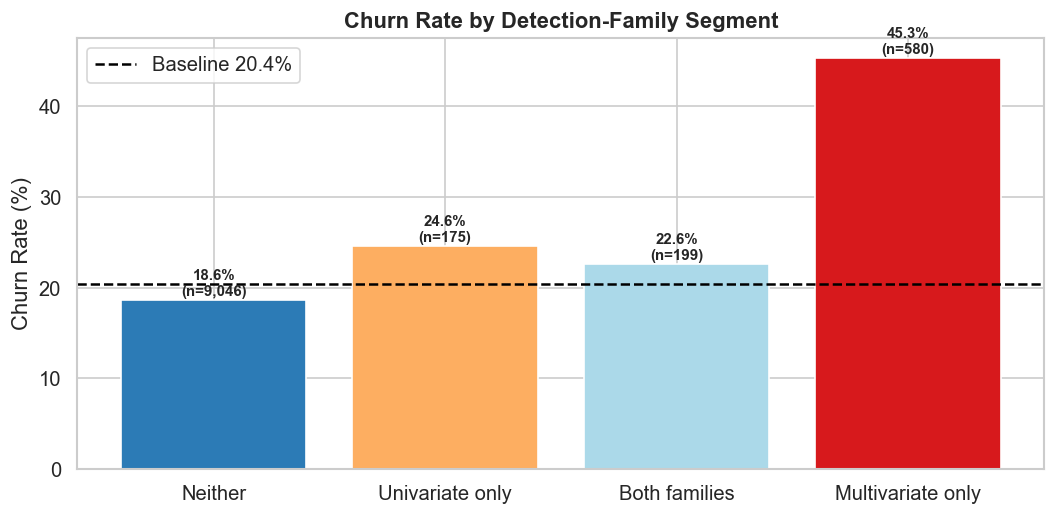

── Decomposition of Disagreements ──
  Multivariate-only pool: 580 records
    Of these, 522 (90%) have NO single feature
    beyond |z| = 3 — anomalous purely as COMBINATIONS, structurally
    invisible to any one-feature-at-a-time screen (IQR / Z-score).
  Univariate-only pool: 175 records
    Single-feature extremes (e.g., age or credit-score tails) that sit in
    otherwise dense, ordinary neighbourhoods — with contamination capped
    at 5% and covariance-aware distance, the multivariate methods do not
    rank them among the most unusual records overall.

── Example MULTIVARIATE-ONLY anomalies (every feature individually 'normal') ──


,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Geography,Exited,Max_Abs_Z,MAHA_dist2
4992,794,62,9,123681.32,3,0,France,1,2.53,25.99
2092,655,38,3,250898.09,3,1,Spain,1,2.80,25.32
1993,824,60,8,134250.17,3,0,Germany,1,2.53,24.83
2495,466,56,2,111920.13,3,0,Germany,1,2.53,23.76
3615,415,46,9,134950.19,3,0,France,1,2.53,23.46
7715,517,62,1,43772.66,3,0,France,1,2.53,23.18
7213,484,55,8,149349.58,3,0,Germany,1,2.53,22.86
538,564,62,5,114931.35,3,1,Germany,1,2.53,22.69
6221,513,45,0,164649.52,3,0,France,1,2.53,21.74
5950,834,57,8,112281.60,3,0,Germany,1,2.53,21.69


── Example UNIVARIATE-ONLY outliers (one extreme feature, ordinary otherwise) ──


,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Geography,Exited,Max_Abs_Z,MAHA_dist2
9333,755,78,5,121206.96,1,1,France,0,3.73,21.19
4590,635,78,6,47536.40,1,1,France,0,3.73,20.74
7375,639,77,6,80926.02,2,1,France,0,3.63,21.40
6167,657,75,7,126273.95,1,1,Spain,0,3.44,17.67
4644,712,74,5,0.00,2,0,Spain,0,3.34,19.92



── INTERPRETATION: WHY UNIVARIATE AND MULTIVARIATE RESULTS DIFFER ──

1. DIFFERENT DEFINITIONS OF 'UNUSUAL'. IQR / Z-score ask: 'is this value extreme
   for this one feature?' Mahalanobis / LOF / Isolation Forest ask: 'is this
   whole customer profile improbable given how the features co-vary?' These are
   different questions, so different records are flagged.

2. COMBINATION ANOMALIES ARE INVISIBLE TO UNIVARIATE SCREENS. The multivariate-
   only examples above (e.g., very young customers holding large balances, or
   multi-product holders with contradictory engagement patterns) have every
   individual value inside normal range — only the joint configuration is rare.

3. MARGINAL EXTREMES ARE NOT ALWAYS MULTIVARIATE OUTLIERS. A customer in the age
   tail whose remaining profile is textbook-typical lies close to the bulk of
   the data in 6-D space; univariate screens flag them, multivariate ones need
   not.

4. DISCOVERY VALUE. The churn rate in the multivariate-only segment is

In [8]:
# ── Univariate vs. Multivariate: Systematic Comparison ───────────────────────
from sklearn.metrics import cohen_kappa_score

UNI_METHODS = ['IQR_flag', 'ZScore_flag']
MV_METHODS  = ['MAHA_flag', 'LOF_flag', 'IF_flag']

df_anomaly['UNI_flag'] = (df_anomaly[UNI_METHODS].sum(axis=1) > 0).astype(int)
df_anomaly['MV_flag']  = (df_anomaly[MV_METHODS].sum(axis=1) > 0).astype(int)

method_summary = pd.DataFrame([
    {'Method': m, 'Type': t, 'Flagged': int(df_anomaly[m].sum()),
     '% of Data': round(df_anomaly[m].mean() * 100, 2),
     'Churn Rate (%)': round(df_anomaly.loc[df_anomaly[m] == 1, 'Exited'].mean() * 100, 1)}
    for m, t in [('IQR_flag', 'Univariate'), ('ZScore_flag', 'Univariate'),
                 ('MAHA_flag', 'Multivariate'), ('LOF_flag', 'Multivariate'),
                 ('IF_flag', 'Multivariate')]
])
print("── Per-Method Summary ──")
display(method_summary)

seg = np.select(
    [(df_anomaly['UNI_flag'] == 1) & (df_anomaly['MV_flag'] == 1),
     (df_anomaly['UNI_flag'] == 1) & (df_anomaly['MV_flag'] == 0),
     (df_anomaly['UNI_flag'] == 0) & (df_anomaly['MV_flag'] == 1)],
    ['Both families', 'Univariate only', 'Multivariate only'],
    default='Neither')
df_anomaly['UniMV_Segment'] = seg

seg_stats = (df_anomaly.groupby('UniMV_Segment')
             .agg(N=('Exited', 'size'), Churn_Rate=('Exited', 'mean')))
seg_stats['Churn Rate (%)'] = (seg_stats['Churn_Rate'] * 100).round(1)
seg_order = ['Neither', 'Univariate only', 'Both families', 'Multivariate only']
seg_stats = seg_stats.reindex(seg_order)

both_n = int(seg_stats.loc['Both families', 'N'])
uni_n  = int(seg_stats.loc['Univariate only', 'N'])
mv_n   = int(seg_stats.loc['Multivariate only', 'N'])
jaccard = both_n / (both_n + uni_n + mv_n)
kappa   = cohen_kappa_score(df_anomaly['UNI_flag'], df_anomaly['MV_flag'])

print("── Family-Level Agreement: Univariate (IQR ∪ Z) vs Multivariate (MAHA ∪ LOF ∪ IF) ──")
display(seg_stats[['N', 'Churn Rate (%)']])
print(f"  Jaccard overlap: {jaccard:.3f} | Cohen's kappa: {kappa:.3f}")
print("  -> Low overlap is NOT a defect: the two families are looking for")
print("     different kinds of 'unusual', decomposed below.")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#2c7bb6', '#fdae61', '#abd9e9', '#d7191c']
bars = ax.bar(seg_stats.index, seg_stats['Churn Rate (%)'], color=colors)
ax.axhline(df_anomaly['Exited'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f"Baseline {df_anomaly['Exited'].mean()*100:.1f}%")
for bar, (_, row) in zip(bars, seg_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + .5,
            f"{row['Churn Rate (%)']:.1f}%\n(n={int(row['N']):,})",
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by Detection-Family Segment', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

# ── WHY the families disagree: decomposition of the disagreement pools ───────
z_all = np.abs(stats.zscore(df_anomaly[scale_cols].values))
df_anomaly['Max_Abs_Z'] = z_all.max(axis=1)

mv_only_mask  = df_anomaly['UniMV_Segment'] == 'Multivariate only'
uni_only_mask = df_anomaly['UniMV_Segment'] == 'Univariate only'

hidden = int((df_anomaly.loc[mv_only_mask, 'Max_Abs_Z'] < 3).sum())
print(f"── Decomposition of Disagreements ──")
print(f"  Multivariate-only pool: {mv_only_mask.sum():,} records")
print(f"    Of these, {hidden:,} ({hidden / mv_only_mask.sum() * 100:.0f}%) have NO single feature")
print(f"    beyond |z| = 3 — anomalous purely as COMBINATIONS, structurally")
print(f"    invisible to any one-feature-at-a-time screen (IQR / Z-score).")
print(f"  Univariate-only pool: {uni_only_mask.sum():,} records")
print(f"    Single-feature extremes (e.g., age or credit-score tails) that sit in")
print(f"    otherwise dense, ordinary neighbourhoods — with contamination capped")
print(f"    at 5% and covariance-aware distance, the multivariate methods do not")
print(f"    rank them among the most unusual records overall.")

example_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                'IsActiveMember', 'Geography', 'Exited', 'Max_Abs_Z', 'MAHA_dist2']
print("\n── Example MULTIVARIATE-ONLY anomalies (every feature individually 'normal') ──")
display(df_anomaly.loc[mv_only_mask & (df_anomaly['Max_Abs_Z'] < 3)]
        .sort_values('MAHA_dist2', ascending=False)[example_cols].head(10).round(2))

print("── Example UNIVARIATE-ONLY outliers (one extreme feature, ordinary otherwise) ──")
display(df_anomaly.loc[uni_only_mask]
        .sort_values('Max_Abs_Z', ascending=False)[example_cols].head(5).round(2))

print("""
── INTERPRETATION: WHY UNIVARIATE AND MULTIVARIATE RESULTS DIFFER ──

1. DIFFERENT DEFINITIONS OF 'UNUSUAL'. IQR / Z-score ask: 'is this value extreme
   for this one feature?' Mahalanobis / LOF / Isolation Forest ask: 'is this
   whole customer profile improbable given how the features co-vary?' These are
   different questions, so different records are flagged.

2. COMBINATION ANOMALIES ARE INVISIBLE TO UNIVARIATE SCREENS. The multivariate-
   only examples above (e.g., very young customers holding large balances, or
   multi-product holders with contradictory engagement patterns) have every
   individual value inside normal range — only the joint configuration is rare.

3. MARGINAL EXTREMES ARE NOT ALWAYS MULTIVARIATE OUTLIERS. A customer in the age
   tail whose remaining profile is textbook-typical lies close to the bulk of
   the data in 6-D space; univariate screens flag them, multivariate ones need
   not.

4. DISCOVERY VALUE. The churn rate in the multivariate-only segment is the
   highest of all four segments — the combination anomalies that univariate
   methods MISS are precisely the records most associated with churn. This is a
   direct answer to the KDD question 'what did we find that was not obvious?':
   the risk signal lives in unusual FEATURE COMBINATIONS, not in extreme single
   values.
""")


#### Findings — why the method families disagree

IQR and Z-score flag marginal extremes one feature at a time. Mahalanobis, LOF, and Isolation Forest flag unusual combinations or sparse neighbourhoods. The executable comparison above is the authoritative table: it reports each count, churn lens, family overlap, and examples of records that one family sees while the other does not. This extension deepens the required IQR/Z-score/Isolation Forest comparison; it does not replace those three graded methods.

In [9]:
# ── Retrospective high-value exited subset (not a pre-churn detector) ─────
print('=' * 70)
print(' RETROSPECTIVE SUBSET: HIGH-BALANCE CUSTOMERS WITH EXITED=1')
print('=' * 70)

balance_75th = df['Balance'].quantile(0.75)
balance_90th = df['Balance'].quantile(0.90)
high_bal_churn = df[(df['Balance'] > balance_75th) & (df['Exited'] == 1)].copy()
high_bal_retained = df[(df['Balance'] > balance_75th) & (df['Exited'] == 0)].copy()

print(f'\n  Balance 75th percentile: {balance_75th:,.0f} balance units')
print(f'  Balance 90th percentile: {balance_90th:,.0f} balance units')
print(f'  High-balance + exited:   {len(high_bal_churn):,} records')
print(f'  High-balance + retained: {len(high_bal_retained):,} records')
print(f'  High-balance churn lens: {len(high_bal_churn)/(len(high_bal_churn)+len(high_bal_retained)):.1%}')
print(f"  Full-dataset churn lens: {df['Exited'].mean():.1%}")

display(high_bal_churn[['CreditScore', 'Age', 'Tenure', 'Balance',
                        'NumOfProducts', 'IsActiveMember', 'Geography']].describe().round(2))
display(high_bal_churn['Geography'].value_counts().rename('Count').to_frame()
        .assign(**{'% of subset': lambda x: (x['Count']/len(high_bal_churn)*100).round(1)}))

# Compatibility field for the dashboard. It is descriptive and is NOT used by
# the anomaly-classification rules below.
df_anomaly['HighBal_Churn_flag'] = (
    (df['Balance'] > balance_75th) & (df['Exited'] == 1)
).astype(int)

print('''
Interpretation boundary:
This cross-sectional snapshot contains no prior-balance or closure timestamp,
so it cannot detect a sudden balance drop or establish temporal pre-churn
behaviour. The subset only quantifies financially material historical exits.
A real early-warning test requires longitudinal balances and event dates.''')

 RETROSPECTIVE SUBSET: HIGH-BALANCE CUSTOMERS WITH EXITED=1

  Balance 75th percentile: 127,644 balance units
  Balance 90th percentile: 149,245 balance units
  High-balance + exited:   592 records
  High-balance + retained: 1,908 records
  High-balance churn lens: 23.7%
  Full-dataset churn lens: 20.4%


,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember
count,592.00,592.00,592.00,592.00,592.00,592.00
mean,647.52,44.29,5.03,149754.95,1.47,0.36
std,99.65,9.91,2.94,19786.27,0.82,0.48
min,350.00,21.00,0.00,127655.22,1.00,0.00
25%,581.00,38.00,2.00,134954.56,1.00,0.00
50%,648.50,44.00,5.00,144356.21,1.00,0.00
75%,713.00,51.00,8.00,158621.56,2.00,1.00
max,850.00,72.00,10.00,250898.09,4.00,1.00


,Count,% of subset
Geography,,
Germany,274,46.3
France,214,36.1
Spain,104,17.6



Interpretation boundary:
This cross-sectional snapshot contains no prior-balance or closure timestamp,
so it cannot detect a sudden balance drop or establish temporal pre-churn
behaviour. The subset only quantifies financially material historical exits.
A real early-warning test requires longitudinal balances and event dates.


In [10]:
# ── Cross-Reference: DBSCAN Noise vs. Statistical Anomalies ──────────────────
dbscan_outlier_idx = np.load(DBSCAN_OUTLIERS_PATH)

df_anomaly['DBSCAN_flag'] = 0
df_anomaly.iloc[dbscan_outlier_idx, 
                df_anomaly.columns.get_loc('DBSCAN_flag')] = 1

# ── Composite Anomaly Score ────────────────────────────────────────────────────
anomaly_flag_cols = ['IQR_flag', 'ZScore_flag', 'IF_flag', 'DBSCAN_flag']
df_anomaly['Composite_Anomaly_Score'] = df_anomaly[anomaly_flag_cols].sum(axis=1)

# ── Venn Analysis ─────────────────────────────────────────────────────────────
print("── CROSS-REFERENCE: Anomaly Method Agreement ──")
print(f"  Flagged by 0 methods: {(df_anomaly['Composite_Anomaly_Score']==0).sum():,}")
print(f"  Flagged by 1 method:  {(df_anomaly['Composite_Anomaly_Score']==1).sum():,}")
print(f"  Flagged by 2 methods: {(df_anomaly['Composite_Anomaly_Score']==2).sum():,}")
print(f"  Flagged by 3 methods: {(df_anomaly['Composite_Anomaly_Score']==3).sum():,}")
print(f"  Flagged by 4 methods: {(df_anomaly['Composite_Anomaly_Score']==4).sum():,}")

# Churn rate by composite score
composite_churn = df_anomaly.groupby('Composite_Anomaly_Score')['Exited'].agg(
    ['mean','sum','count']
).rename(columns={'mean':'Churn Rate','sum':'Churned','count':'Total'})
composite_churn['Churn Rate (%)'] = (composite_churn['Churn Rate'] * 100).round(1)
print(f"\n── Churn Rate by Composite Anomaly Score ──")
display(composite_churn[['Churn Rate (%)','Churned','Total']])

# ── Corroborated candidates (the rubric's 2+ method definition) ─────────────
corroborated_anomalies = df_anomaly[
    df_anomaly['Composite_Anomaly_Score'] >= 2
].copy()
print(f"\n── CORROBORATED ANOMALIES (flagged by ≥ 2 core methods) ──")
print(f"  Count: {len(corroborated_anomalies):,}")
print(f"  Churn alignment: {corroborated_anomalies['Exited'].mean()*100:.1f}%")
display(corroborated_anomalies[[
    'Source_RowNumber', 'CreditScore', 'Age', 'Balance', 'NumOfProducts',
    'IsActiveMember', 'Exited', 'Geography', 'Composite_Anomaly_Score'
]].head(20))
print('\n  Reports are persisted after the evidence-based typology is assigned below.')

── CROSS-REFERENCE: Anomaly Method Agreement ──
  Flagged by 0 methods: 9,124
  Flagged by 1 method:  423
  Flagged by 2 methods: 287
  Flagged by 3 methods: 92
  Flagged by 4 methods: 74

── Churn Rate by Composite Anomaly Score ──


,Churn Rate (%),Churned,Total
Composite_Anomaly_Score,,,
0,17.7,1612,9124
1,47.3,200,423
2,65.9,189,287
3,25.0,23,92
4,17.6,13,74



── CORROBORATED ANOMALIES (flagged by ≥ 2 core methods) ──
  Count: 453
  Churn alignment: 49.7%


,Source_RowNumber,CreditScore,Age,Balance,NumOfProducts,IsActiveMember,Exited,Geography,Composite_Anomaly_Score
2,3,502,42,159660.80,3,0,1,France,2
7,8,376,29,115046.74,4,0,1,Germany,3
29,30,411,29,59697.17,2,1,0,France,2
58,59,511,66,0.00,1,0,1,Spain,3
70,71,738,58,133745.44,4,0,1,Germany,2
85,86,652,75,0.00,2,1,0,Spain,3
104,105,670,65,0.00,1,1,1,Spain,2
158,159,646,73,97259.25,1,1,0,France,2
181,182,510,65,0.00,2,1,0,France,2
230,231,673,72,0.00,2,1,0,France,2



  Reports are persisted after the evidence-based typology is assigned below.


In [11]:
# Pairwise Anomaly Method Agreement
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

def jaccard_binary(left, right):
    intersection = ((df_anomaly[left] == 1) & (df_anomaly[right] == 1)).sum()
    union = ((df_anomaly[left] == 1) | (df_anomaly[right] == 1)).sum()
    return intersection / union if union else 0

agreement_rows = []
for left, right in combinations(anomaly_flag_cols, 2):
    agreement_rows.append({
        'Method Pair': f'{left} vs {right}',
        'Intersection': int(((df_anomaly[left] == 1) & (df_anomaly[right] == 1)).sum()),
        'Jaccard': round(jaccard_binary(left, right), 3),
        'Cohen_Kappa': round(cohen_kappa_score(df_anomaly[left], df_anomaly[right]), 3)
    })

method_agreement = pd.DataFrame(agreement_rows).sort_values('Jaccard', ascending=False)
print("Pairwise Agreement Between Anomaly Methods")
display(method_agreement)


Pairwise Agreement Between Anomaly Methods


,Method Pair,Intersection,Jaccard,Cohen_Kappa
5,IF_flag vs DBSCAN_flag,336,0.468,0.617
0,IQR_flag vs ZScore_flag,141,0.377,0.538
1,IQR_flag vs IF_flag,188,0.274,0.405
2,IQR_flag vs DBSCAN_flag,159,0.207,0.312
3,ZScore_flag vs IF_flag,104,0.194,0.309
4,ZScore_flag vs DBSCAN_flag,79,0.128,0.210


In [12]:
# ── Post-hoc churn alignment for appendix (NOT anomaly ground truth) ───────
candidate_mask = df_anomaly['Composite_Anomaly_Score'] >= 1
corroborated_mask = df_anomaly['Composite_Anomaly_Score'] >= 2
y_observed = df_anomaly['Exited'].astype(bool)

tp = int((corroborated_mask & y_observed).sum())
fp = int((corroborated_mask & ~y_observed).sum())
fn = int((~corroborated_mask & y_observed).sum())
tn = int((~corroborated_mask & ~y_observed).sum())
churn_alignment_precision = tp / (tp + fp)
churn_alignment_recall = tp / (tp + fn)
churn_alignment_f1 = (
    2 * churn_alignment_precision * churn_alignment_recall
    / (churn_alignment_precision + churn_alignment_recall)
)

alignment_table = pd.DataFrame(
    [[tp, fp], [fn, tn]],
    index=['Corroborated (2+)', 'Not corroborated'],
    columns=['Exited=1', 'Exited=0'],
)
print('Post-hoc alignment of 2+ method anomaly corroboration with Exited')
display(alignment_table)
print(f'  Precision-like alignment: {churn_alignment_precision:.1%}')
print(f'  Recall-like alignment:    {churn_alignment_recall:.1%}')
print(f'  F1-like alignment:        {churn_alignment_f1:.1%}')
print('  IMPORTANT: Exited is a business outcome label, not anomaly ground truth. ')
print('  These values describe overlap only; they are not model accuracy.')

phase4_metric_rows = [
    {'Phase': 'Phase 4', 'Metric': 'Anomaly candidates before corroboration', 'Value': int(candidate_mask.sum()), 'Unit': 'records',
     'Definition': 'Union of IQR, Z-score, Isolation Forest, and Phase 2 DBSCAN flags.', 'Source': 'phase4_anomaly_detection.ipynb'},
    {'Phase': 'Phase 4', 'Metric': 'Corroborated anomalies (2+ methods)', 'Value': int(corroborated_mask.sum()), 'Unit': 'records',
     'Definition': 'Candidates flagged by at least two of the four core methods.', 'Source': 'phase4_anomaly_detection.ipynb'},
    {'Phase': 'Phase 4', 'Metric': 'Precision-like churn alignment (2+ methods)', 'Value': churn_alignment_precision, 'Unit': 'proportion',
     'Definition': 'Exited share among 2+ method candidates; Exited is not anomaly ground truth.', 'Source': 'phase4_anomaly_detection.ipynb'},
    {'Phase': 'Phase 4', 'Metric': 'Recall-like churn alignment (2+ methods)', 'Value': churn_alignment_recall, 'Unit': 'proportion',
     'Definition': 'Share of Exited=1 records in the 2+ method pool; not predictive recall.', 'Source': 'phase4_anomaly_detection.ipynb'},
    {'Phase': 'Phase 4', 'Metric': 'F1-like churn alignment (2+ methods)', 'Value': churn_alignment_f1, 'Unit': 'score',
     'Definition': 'Harmonic summary of overlap metrics; not anomaly accuracy.', 'Source': 'phase4_anomaly_detection.ipynb'},
]
phase4_metrics = upsert_evaluation_metrics(phase4_metric_rows)
display(phase4_metrics[phase4_metrics['Phase'] == 'Phase 4'])

Post-hoc alignment of 2+ method anomaly corroboration with Exited


,Exited=1,Exited=0
Corroborated (2+),225,228
Not corroborated,1812,7735


  Precision-like alignment: 49.7%
  Recall-like alignment:    11.0%
  F1-like alignment:        18.1%
  IMPORTANT: Exited is a business outcome label, not anomaly ground truth. 
  These values describe overlap only; they are not model accuracy.


,Phase,Metric,Value,Unit,Definition,Source
19,Phase 4,Anomaly candidates before corroboration,876.000000,records,"Union of IQR, Z-score, Isolation Forest, and P...",phase4_anomaly_detection.ipynb
20,Phase 4,Corroborated anomalies (2+ methods),453.000000,records,Candidates flagged by at least two of the four...,phase4_anomaly_detection.ipynb
21,Phase 4,F1-like churn alignment (2+ methods),0.180723,score,Harmonic summary of overlap metrics; not anoma...,phase4_anomaly_detection.ipynb
22,Phase 4,Precision-like churn alignment (2+ methods),0.496689,proportion,Exited share among 2+ method candidates; Exite...,phase4_anomaly_detection.ipynb
23,Phase 4,Recall-like churn alignment (2+ methods),0.110457,proportion,Share of Exited=1 records in the 2+ method poo...,phase4_anomaly_detection.ipynb


### Interpretation — The Composite-Score Paradox, and What Method Agreement Actually Measures

The churn-by-score table is deliberately *non-monotonic*, and explaining it blocks the most tempting wrong conclusion ("more methods agreeing = more risk"):

- **Score 2 is the churn peak (65.9%), not score 4.** 71% of the score-2 pool is precisely the {Isolation Forest + DBSCAN} pair — the two structural methods agreeing while both univariate fences stay silent. These are combination anomalies (mean age ≈ 52): unusual *profiles* built from individually normal values, and heavily churn-loaded.
- **Scores 3–4 select a different species entirely (churn 25.0% / 17.6%).** To be flagged by ≥3 of the 4 methods, a record must *also* break a univariate fence — and those fences fire almost exclusively on extreme age. The ≥3 pool is therefore dominated by records aged 61+: mean age 70.6, 95% aged 60+, 39% zero-balance. Statistically extreme in every direction, behaviorally settled — rare-but-legitimate older customers, not risk signals. Their churn (21.7%) is near baseline.
- **So "consensus" here measures univariate visibility, not severity.** Two of the four voters are univariate; unanimity therefore structurally favors single-feature extremes — exactly the anomaly type this phase shows to be *least* churn-relevant. A naive "escalate score-4 first" policy would chase retirees while missing the score-2 structural pool where risk actually concentrates.
- **The pairwise table quantifies the family structure:** strongest agreement IF ↔ DBSCAN (κ = 0.617) — two structurally different multivariate mechanisms (tree isolation vs. density) converging on the same customers, which is mutual validation; weakest Z-score ↔ DBSCAN (κ = 0.21) — a strict single-feature fence vs. a joint-density method barely overlap, exactly as the family analysis predicts.

**Conclusion:** anomaly votes are not exchangeable and must be weighted by what question each voter asks. For churn-risk triage, the {IF ∩ DBSCAN} intersection is the high-value list; the univariate flags are the right pool for data-quality review and rare-case documentation. This is the operational payoff of the systematic method comparison the rubric requires.


In [13]:
# ── Evidence-based anomaly typology (does not use Exited) ───────────────
BALANCE_SCENARIO_CUT = 100000

def classify_anomaly(row):
    if row['Composite_Anomaly_Score'] == 0:
        return ('Normal — Not Flagged', 'No core detector flagged the record.', 'Routine handling.')

    impossible = (
        not 300 <= row['CreditScore'] <= 850
        or not 18 <= row['Age'] <= 100
        or not 0 <= row['Tenure'] <= 10
        or row['Balance'] < 0
        or row['NumOfProducts'] not in {1, 2, 3, 4}
        or row['HasCrCard'] not in {0, 1}
        or row['IsActiveMember'] not in {0, 1}
    )
    if impossible:
        return ('A: Data Error', 'Value outside the Phase 1 documented domain rules.',
                'Verify against the source system before business use.')

    if row['Age'] > 90:
        return ('B: Rare Legitimate — Source Verification Recommended',
                'Admissible age above 90 plus at least one detector flag.',
                'Verify age; retain if confirmed.')

    if row['IF_flag'] == 1 and row['DBSCAN_flag'] == 1:
        return ('C: Risk Signal — IF + DBSCAN Consensus',
                'Tree isolation and density rarity independently flag the same profile.',
                'Prioritize a human review; test a retention treatment, not an automatic decision.')
    if row['DBSCAN_flag'] == 1:
        return ('C: Risk Signal — DBSCAN Density Outlier',
                'Phase 2 places the record outside dense customer neighbourhoods.',
                'Review the unusual feature combination and monitor engagement.')

    arm_profile_overlap = (
        (46 <= row['Age'] <= 60 and row['IsActiveMember'] == 0 and row['NumOfProducts'] == 1)
        or (row['Geography'] == 'Germany' and row['IsActiveMember'] == 0 and row['NumOfProducts'] == 1)
        or (row['Balance'] > BALANCE_SCENARIO_CUT and row['IsActiveMember'] == 0 and row['NumOfProducts'] == 1)
    )
    if arm_profile_overlap:
        return ('C: Risk Signal — ARM Profile Overlap',
                'An anomaly flag overlaps a Phase 3 churn-associated engagement profile.',
                'Validate out of time, then test re-engagement / relationship-depth actions.')

    if row['Age'] < 22 and row['Balance'] > 50000:
        return ('B: Rare Legitimate — Young High-Balance Customer',
                'Uncommon age/balance combination within documented bounds.',
                'Verify and offer appropriate service; do not delete.')
    if row['NumOfProducts'] == 4:
        return ('B: Rare Legitimate — Maximum Product Holder',
                'Maximum observed product count but still inside the documented range.',
                'Retain; review product suitability and service needs.')
    return ('B: Rare Legitimate — Statistical/Isolation Outlier',
            'Flagged statistically or by Isolation Forest without structural risk-profile evidence.',
            'Retain and monitor; investigate only if other business evidence emerges.')

classification = df_anomaly.apply(classify_anomaly, axis=1, result_type='expand')
classification.columns = ['Anomaly_Class', 'Anomaly_Evidence', 'Recommended_Action']
df_anomaly[classification.columns] = classification
df_flagged = df_anomaly[candidate_mask].copy()

print(f'── ANOMALY CLASSIFICATION REPORT (n={len(df_flagged):,} flagged records) ──')
class_summary = (df_flagged.groupby('Anomaly_Class')
                 .agg(Count=('Exited', 'size'), Churn_Lens=('Exited', 'mean'))
                 .sort_index())
class_summary['% of Flagged'] = class_summary['Count'] / len(df_flagged) * 100
class_summary['Churn Lens (%)'] = class_summary['Churn_Lens'] * 100
display(class_summary[['Count', '% of Flagged', 'Churn Lens (%)']].round(1))

print('\nExample evidence and action rows')
display(df_flagged[[
    'Source_RowNumber', 'Anomaly_Class', 'Anomaly_Evidence',
    'Recommended_Action', 'Composite_Anomaly_Score', 'Exited'
]].groupby('Anomaly_Class', group_keys=False).head(2))

# Persist only after classifications and record-level evidence exist.
df_anomaly.to_csv(ANOMALY_REPORT_PATH, index=False)
df_anomaly[corroborated_mask].to_csv(HIGH_CONFIDENCE_ANOMALIES_PATH, index=False)
print('\n  Anomaly report and 2+ method corroborated subset saved to outputs/.')

── ANOMALY CLASSIFICATION REPORT (n=876 flagged records) ──


,Count,% of Flagged,Churn Lens (%)
Anomaly_Class,,,
B: Rare Legitimate — Source Verification Recommended,2,0.2,0.0
B: Rare Legitimate — Statistical/Isolation Outlier,273,31.2,16.5
B: Rare Legitimate — Young High-Balance Customer,7,0.8,14.3
C: Risk Signal — ARM Profile Overlap,42,4.8,76.2
C: Risk Signal — DBSCAN Density Outlier,218,24.9,66.1
C: Risk Signal — IF + DBSCAN Consensus,334,38.1,60.8



Example evidence and action rows


,Source_RowNumber,Anomaly_Class,Anomaly_Evidence,Recommended_Action,Composite_Anomaly_Score,Exited
2,3,C: Risk Signal — IF + DBSCAN Consensus,Tree isolation and density rarity independentl...,Prioritize a human review; test a retention tr...,2,1
7,8,C: Risk Signal — IF + DBSCAN Consensus,Tree isolation and density rarity independentl...,Prioritize a human review; test a retention tr...,3,1
30,31,C: Risk Signal — DBSCAN Density Outlier,Phase 2 places the record outside dense custom...,Review the unusual feature combination and mon...,1,1
35,36,C: Risk Signal — ARM Profile Overlap,An anomaly flag overlaps a Phase 3 churn-assoc...,"Validate out of time, then test re-engagement ...",1,1
75,76,B: Rare Legitimate — Young High-Balance Customer,Uncommon age/balance combination within docume...,Verify and offer appropriate service; do not d...,1,0
85,86,B: Rare Legitimate — Statistical/Isolation Out...,Flagged statistically or by Isolation Forest w...,Retain and monitor; investigate only if other ...,3,0
90,91,C: Risk Signal — DBSCAN Density Outlier,Phase 2 places the record outside dense custom...,Review the unusual feature combination and mon...,1,1
104,105,B: Rare Legitimate — Statistical/Isolation Out...,Flagged statistically or by Isolation Forest w...,Retain and monitor; investigate only if other ...,2,1
313,314,C: Risk Signal — ARM Profile Overlap,An anomaly flag overlaps a Phase 3 churn-assoc...,"Validate out of time, then test re-engagement ...",1,0
389,390,B: Rare Legitimate — Young High-Balance Customer,Uncommon age/balance combination within docume...,Verify and offer appropriate service; do not d...,1,0



  Anomaly report and 2+ method corroborated subset saved to outputs/.


### Reading the classification table honestly

The class rules above are fixed **without consulting `Exited`**. Their churn rates can therefore be used as a post-hoc validation lens without the previous 100%-by-construction circularity.

- **Class A — Data error:** violates a documented Phase 1 domain rule. A zero count is a valid result; anomalies need not be errors.
- **Class B — rare legitimate case:** unusual but plausible evidence, with a record-specific reason and action.
- **Class C — risk signal:** independent structural consensus/density evidence or overlap with a Phase 3 engagement profile. It is a review priority, not an automatic adverse decision.

The ARM-overlap subtype is still in-sample triangulation, so it must be validated on a later period. `Exited` remains a business outcome label—not anomaly truth—and the precision/recall-like values above must never be presented as predictive performance.

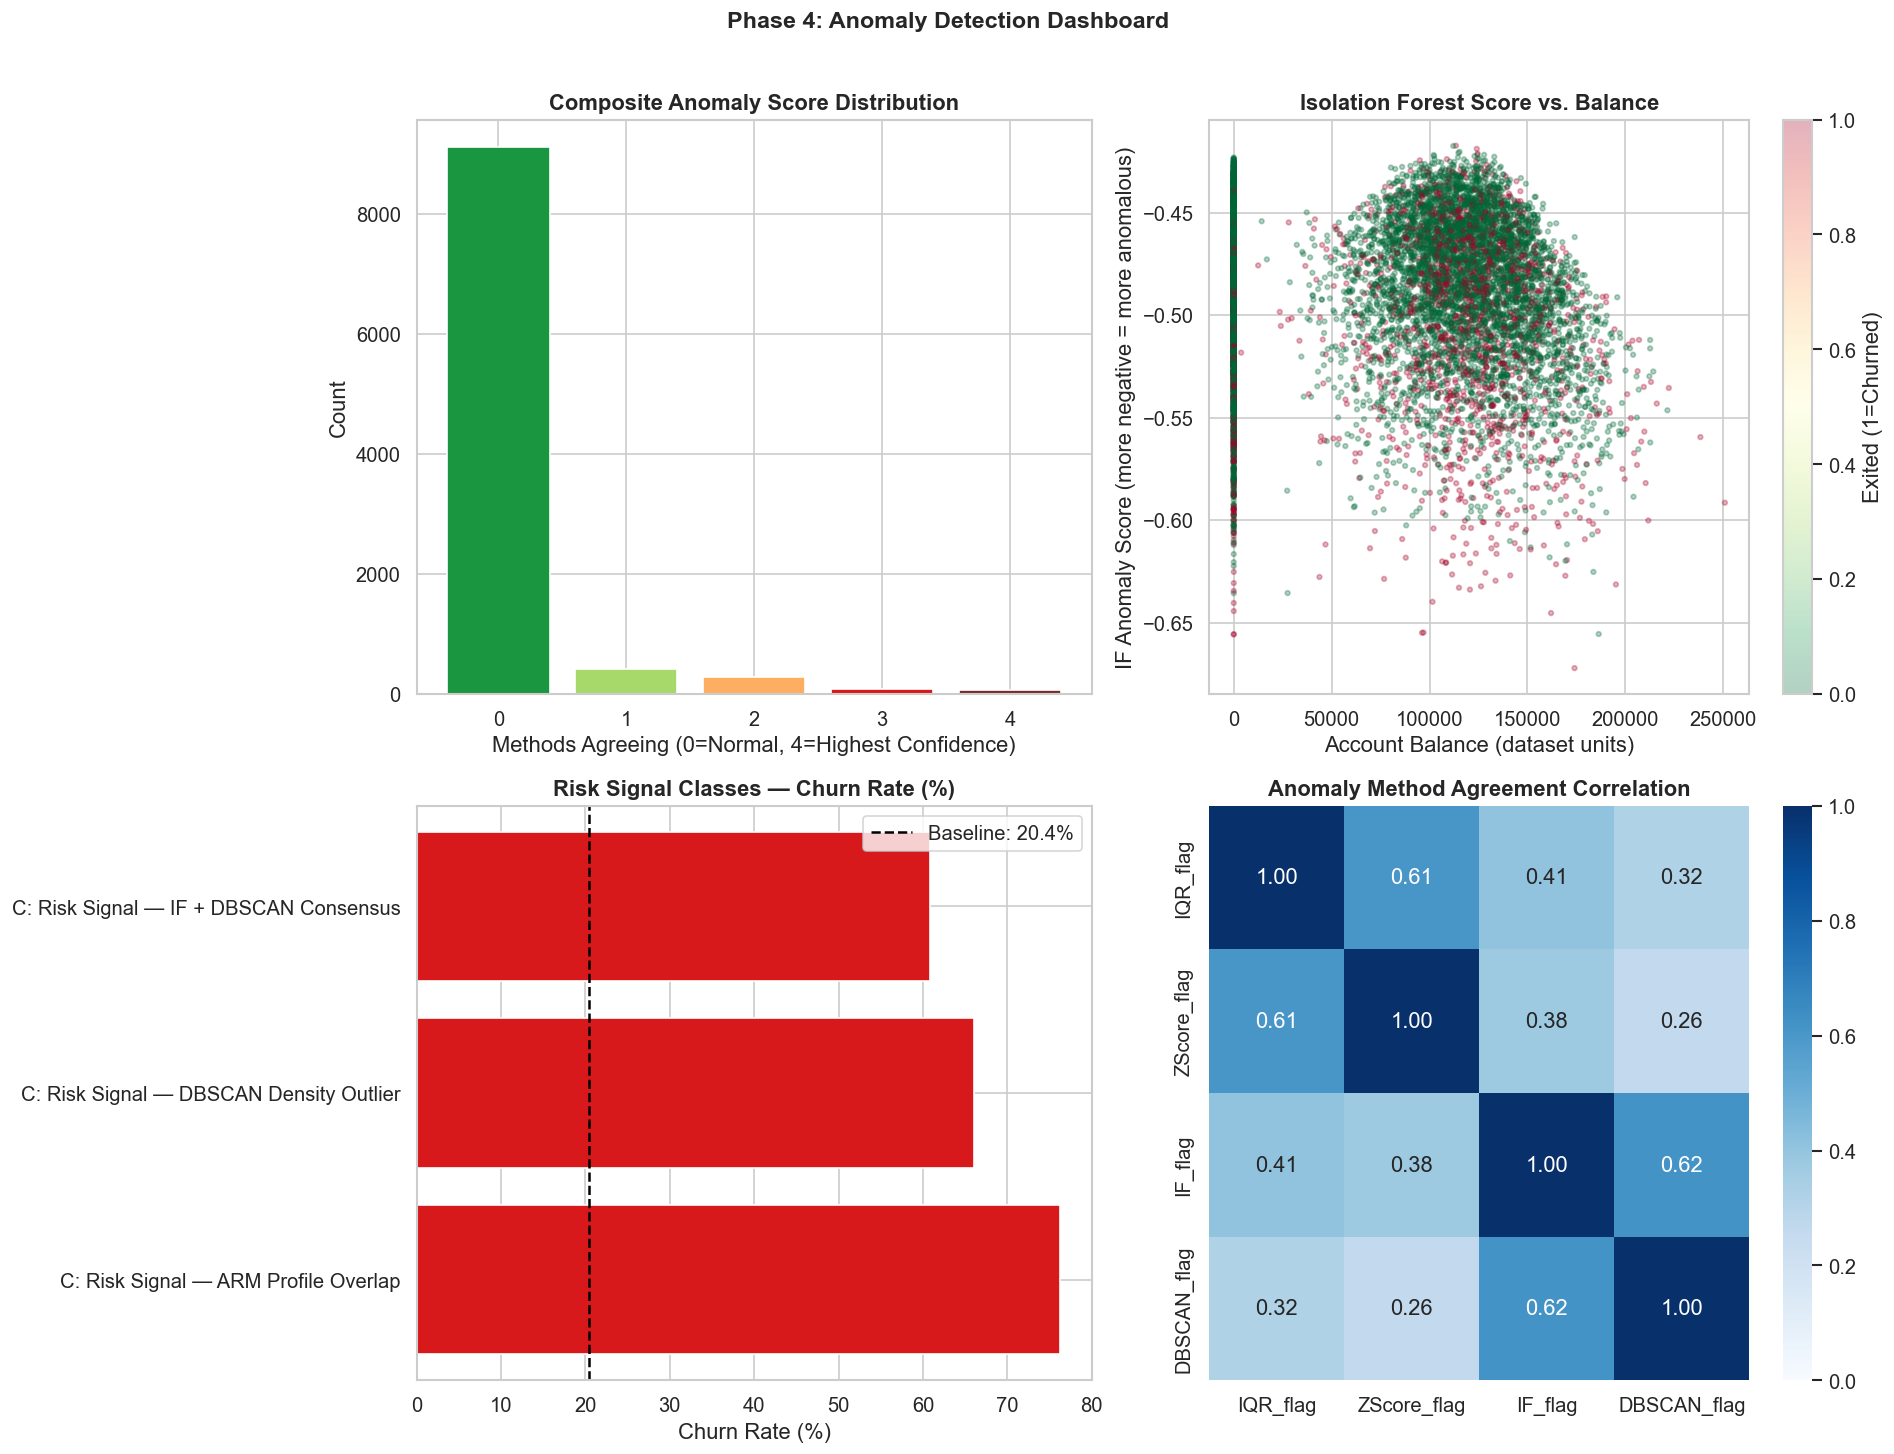

In [14]:
# ── Anomaly Visualization Dashboard ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Composite Anomaly Score Distribution
score_counts = df_anomaly['Composite_Anomaly_Score'].value_counts().sort_index()
axes[0,0].bar(score_counts.index, score_counts.values, 
              color=['#1a9641','#a6d96a','#fdae61','#d7191c','#7b2c2c'])
axes[0,0].set_title('Composite Anomaly Score Distribution', fontweight='bold')
axes[0,0].set_xlabel('Methods Agreeing (0=Normal, 4=Highest Confidence)')
axes[0,0].set_ylabel('Count')

# 2. IF Anomaly Score vs. Balance (colored by Exited)
sc = axes[0,1].scatter(
    df_anomaly['Balance'], df_anomaly['IF_anomaly_score'],
    c=df_anomaly['Exited'], cmap='RdYlGn_r', alpha=0.3, s=8
)
plt.colorbar(sc, ax=axes[0,1], label='Exited (1=Churned)')
axes[0,1].set_title('Isolation Forest Score vs. Balance', fontweight='bold')
axes[0,1].set_xlabel('Account Balance (dataset units)')
axes[0,1].set_ylabel('IF Anomaly Score (more negative = more anomalous)')

# 3. Anomaly Class Churn Rate
class_churn = (df_anomaly[df_anomaly['Anomaly_Class'].str.startswith('C')]
               .groupby('Anomaly_Class')['Exited'].mean() * 100)
if len(class_churn) > 0:
    axes[1,0].barh(class_churn.index, class_churn.values, color='#d7191c')
    axes[1,0].set_title('Risk Signal Classes — Churn Rate (%)', fontweight='bold')
    axes[1,0].set_xlabel('Churn Rate (%)')
    axes[1,0].axvline(df['Exited'].mean()*100, color='black', linestyle='--',
                      label=f'Baseline: {df["Exited"].mean()*100:.1f}%')
    axes[1,0].legend()

# 4. Method Agreement Heatmap
method_matrix = df_anomaly[anomaly_flag_cols].corr()
sns.heatmap(method_matrix, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1,1], vmin=0, vmax=1)
axes[1,1].set_title('Anomaly Method Agreement Correlation', fontweight='bold')

plt.suptitle('Phase 4: Anomaly Detection Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()


In [15]:
method_rows = []
for flag, label in [
    ('IQR_flag', 'IQR (1.5×IQR)'), ('ZScore_flag', 'Z-score (|z|>3)'),
    ('IF_flag', 'Isolation Forest (5%)'), ('MAHA_flag', 'Robust Mahalanobis (extension)'),
    ('LOF_flag', 'LOF (extension)'), ('DBSCAN_flag', 'DBSCAN noise (Phase 2)'),
]:
    mask = df_anomaly[flag] == 1
    method_rows.append({
        'Method': label, 'Flagged': int(mask.sum()),
        '% of Data': round(mask.mean() * 100, 2),
        'Churn Lens (%)': round(df_anomaly.loc[mask, 'Exited'].mean() * 100, 1),
    })
phase4_method_table = pd.DataFrame(method_rows)
display(Markdown('## Phase 4 final evidence summary'))
display(phase4_method_table)
display(class_summary[['Count', '% of Flagged', 'Churn Lens (%)']].round(1))
display(Markdown(f'''**Cross-phase conclusion.** The four required/core methods flag **{candidate_mask.sum():,}** unique candidates; **{corroborated_mask.sum():,}** are corroborated by at least two. IF and DBSCAN provide the strongest structural cross-check, while IQR/Z-score mainly document marginal extremes. The non-circular typology records a reason and recommended action for every flagged source row.

The 2+ method pool has precision-like churn alignment **{churn_alignment_precision:.1%}** and recall-like alignment **{churn_alignment_recall:.1%}**. These are overlap descriptors against `Exited`, not anomaly accuracy or predictive performance.'''))

## Phase 4 final evidence summary

,Method,Flagged,% of Data,Churn Lens (%)
0,IQR (1.5×IQR),374,3.74,23.5
1,Z-score (|z|>3),141,1.41,13.5
2,Isolation Forest (5%),500,5.00,49.0
3,Robust Mahalanobis (extension),117,1.17,65.8
4,LOF (extension),500,5.00,32.4
5,DBSCAN noise (Phase 2),554,5.54,62.6


,Count,% of Flagged,Churn Lens (%)
Anomaly_Class,,,
B: Rare Legitimate — Source Verification Recommended,2,0.2,0.0
B: Rare Legitimate — Statistical/Isolation Outlier,273,31.2,16.5
B: Rare Legitimate — Young High-Balance Customer,7,0.8,14.3
C: Risk Signal — ARM Profile Overlap,42,4.8,76.2
C: Risk Signal — DBSCAN Density Outlier,218,24.9,66.1
C: Risk Signal — IF + DBSCAN Consensus,334,38.1,60.8


**Cross-phase conclusion.** The four required/core methods flag **876** unique candidates; **453** are corroborated by at least two. IF and DBSCAN provide the strongest structural cross-check, while IQR/Z-score mainly document marginal extremes. The non-circular typology records a reason and recommended action for every flagged source row.

The 2+ method pool has precision-like churn alignment **49.7%** and recall-like alignment **11.0%**. These are overlap descriptors against `Exited`, not anomaly accuracy or predictive performance.

## KDD knowledge synthesis — what was not obvious in the raw table?

1. **Interactions carry more knowledge than isolated columns.** Phase 3 finds that age 46–60, inactivity, product depth, geography, and the high-balance scenario become much more informative in combinations; the non-redundancy test ensures each reported extension adds measurable confidence.
2. **Customer segments form a weak but stable continuum.** K=3 is not presented as a perfect natural partition: its silhouette is weak, yet K-Means and Ward agree strongly enough to support interpretable balance/product-depth personas.
3. **Structural rarity differs from extreme values.** IQR/Z-score mostly identify marginal tails. Isolation Forest and Phase 2 DBSCAN converge on unusual joint profiles that are more churn-aligned, showing why a one-column outlier screen misses the key anomaly pattern.
4. **Rare does not mean wrong or risky.** The record-level typology distinguishes domain violations, plausible rarities, and review-worthy structural signals without using churn to manufacture the classes.

These are discovery hypotheses for investigation and controlled testing. They do not establish causality, predictive accuracy, or a right to automate customer treatment.

## Limitations & threats to validity

1. **Cross-sectional data cannot reveal a sudden balance drop.** There is one row per customer and no transaction/closure timeline. The high-balance-exited subset is retrospective; a real early-warning test needs longitudinal balances and event dates.
2. **Weak cluster geometry.** Silhouettes are low. Personas are stable operational partitions of a continuum, not proof of three naturally isolated customer species.
3. **No documented balance/salary currency.** The 100K split is a scenario boundary only. Legal insurance, purchasing-power, and “uninsured money” claims are unsupported.
4. **Discretization and detector settings matter.** Apriori patterns depend on bin boundaries; DBSCAN depends on `eps/min_samples`; Isolation Forest and LOF counts depend on contamination. Sensitivity checks are required before deployment.
5. **Post-hoc, in-sample validation.** `Exited` is used only after discovery, but churn alignment and ARM overlap still come from the same snapshot. Validate out of time and across branches/countries.
6. **Association is not causation.** Geography, gender, age, product depth, and activity patterns may proxy for service, cohort, or market effects. Test interventions and apply fairness safeguards.

The evidence supports deeper investigation and experiment design—not automated churn decisions.